In [63]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from utils import plot_top_n_distribution, calculate_range
import numpy as np

In [64]:
df_charging_data = pd.read_csv('../data/charging_sessions.csv')
df_weather = pd.read_csv('../data/weather_burbank_airport.csv')

### General data overview 

#### EV charging data

In [65]:
df_charging_data.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil..."
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil..."


In [66]:
df_charging_data.describe()

,Unnamed: 0,kWhDelivered,siteID,userID
count,66450.000000,66450.000000,66450.000000,49187.000000
mean,4726.102062,11.787916,1.472656,1800.494582
std,3568.025394,10.314789,0.499256,2617.548614
min,0.000000,0.501000,1.000000,1.000000
25%,1845.000000,5.097000,1.000000,431.000000
50%,3960.000000,9.140000,1.000000,818.000000
75%,7027.000000,14.183000,2.000000,1805.000000
max,15291.000000,108.797242,2.000000,19923.000000


In [67]:
df_charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


In [68]:
df_charging_data.isnull().sum()

Unnamed: 0              0
id                      0
connectionTime          0
disconnectTime          0
doneChargingTime     4088
kWhDelivered            0
sessionID               0
siteID                  0
spaceID                 0
stationID               0
timezone                0
userID              17263
userInputs          17263
dtype: int64

#### Weather data

In [69]:
df_weather.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0


In [70]:
df_weather.describe()

,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature
count,29219.000000,29224.000000,29236.000000,29158.000000,29244.000000,29218.000000
mean,17.885622,30.107993,986.879400,8.566568,0.059360,17.731433
std,6.454604,5.400388,3.607065,6.699889,0.471682,6.321100
min,2.000000,4.000000,971.000000,0.000000,0.000000,0.000000
25%,13.000000,26.000000,984.500000,6.000000,0.000000,13.000000
50%,17.000000,33.000000,986.480000,7.000000,0.000000,17.000000
75%,22.000000,34.000000,989.110000,13.000000,0.000000,22.000000
max,46.000000,47.000000,999.650000,57.000000,18.540000,42.000000


In [71]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29244 entries, 0 to 29243
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     29244 non-null  object 
 1   timestamp                29244 non-null  object 
 2   temperature              29219 non-null  float64
 3   cloud_cover              29224 non-null  float64
 4   cloud_cover_description  29224 non-null  object 
 5   pressure                 29236 non-null  float64
 6   windspeed                29158 non-null  float64
 7   precipitation            29244 non-null  float64
 8   felt_temperature         29218 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


### Data preparation

#### Weather Data

In [72]:
weather_profile = ProfileReport(df_weather, title="Profiling Report on Weather Data")
# weather_profile.to_file("weather_data_report.html")

In [73]:
# Transform date:
df_weather["timestamp"] = df_weather["timestamp"].apply(
    lambda x: pd.to_datetime(x, utc=True))
# Transform the timestamps from UTC to the correct timezone
df_weather["timestamp"] = df_weather["timestamp"].apply(lambda x: x.tz_convert('America/Los_Angeles'))

In [74]:
# Check for null values
missing_values_w = df_weather.isnull().sum()
missing_values_w

city                        0
timestamp                   0
temperature                25
cloud_cover                20
cloud_cover_description    20
pressure                    8
windspeed                  86
precipitation               0
felt_temperature           26
dtype: int64

Now we can handle the missing values. As it is time series data with one hour in between each record, it is likely that the values are very similar to the previous ones. That's why we fill missing values with the previous value.

In [75]:
# Fill missing values with the previous value
df_weather = df_weather.ffill()

In [76]:
# Add a column with timestamps rounded to the nearest hour (for later merging with charging data)
df_weather["rounded_timestamp"] = df_weather["timestamp"].dt.ceil("h", ambiguous='NaT', nonexistent='NaT')

In [77]:
# Check if rounded timestamps are unique
df_weather["rounded_timestamp"].is_unique

False

In [78]:
# Analyze duplicates
duplicates = df_weather.groupby('rounded_timestamp').size()
non_unique_rounded_timestamps = duplicates[duplicates > 1].index
non_unique_rows_df = df_weather[df_weather['rounded_timestamp'].isin(non_unique_rounded_timestamps)]
non_unique_rows_df[['timestamp', 'rounded_timestamp']].head()

,timestamp,rounded_timestamp
150,2018-01-07 06:36:00-08:00,2018-01-07 07:00:00-08:00
151,2018-01-07 06:41:00-08:00,2018-01-07 07:00:00-08:00
152,2018-01-07 06:53:00-08:00,2018-01-07 07:00:00-08:00
153,2018-01-07 07:30:00-08:00,2018-01-07 08:00:00-08:00
154,2018-01-07 07:53:00-08:00,2018-01-07 08:00:00-08:00


In the weather data there are sometimes multiple measurements during the same hour. To avoid duplicates when joining the weather data and hourly charging data, we will only take the last measurement (minute 53) for each hour.

In [79]:
# Filter weather_df to only include rows where the minute is 53
df_weather_filtered = df_weather[df_weather['timestamp'].dt.minute == 53]
df_weather_filtered.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,Burbank,2018-01-01 00:53:00-08:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0,2018-01-01 01:00:00-08:00
1,Burbank,2018-01-01 01:53:00-08:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0,2018-01-01 02:00:00-08:00
2,Burbank,2018-01-01 02:53:00-08:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0,2018-01-01 03:00:00-08:00
3,Burbank,2018-01-01 03:53:00-08:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0,2018-01-01 04:00:00-08:00
4,Burbank,2018-01-01 04:53:00-08:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0,2018-01-01 05:00:00-08:00


#### EV charging Data

#### Drop duplicates

In [80]:
# Remove the "Unnamed: 0" column, as it represents the index and restarts from 1 at a certain point in the dataset
df_charging_data = df_charging_data.drop(columns=["Unnamed: 0"])

In [81]:
# Check for duplicates
duplicate_rows = df_charging_data.duplicated()
duplicate_count = duplicate_rows.sum()
duplicate_percentage = round(duplicate_count / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of duplicate rows in the data: {duplicate_count}")
print(f"Percentage of duplicate rows in the data: {duplicate_percentage}%")

Absolute number of duplicate rows in the data: 1413
Percentage of duplicate rows in the data: 2.13%


In [82]:
# Drop duplicate rows
df_charging_data = df_charging_data.drop_duplicates()
len(df_charging_data)

65037

#### Normalize nested data 

A nested JSON structure for the column "userInputs" can be seen. 
To make it easier to analyze the data, the nested structure should be broken down into multiple columns. 
Some of the rows might have multiple user inputs with different timestamps. 
-> These rows should be looked at more closely first.

In [83]:
df_charging_data = df_charging_data.copy()

# For column userInputs: Change string representation of Python list into a list to be able to count the length
df_charging_data.loc[:, 'userInputs'] = df_charging_data['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else None
)

# Count the number of entries in each list
df_charging_data.loc[:, 'inputCount'] = df_charging_data['userInputs'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

In [84]:
df_charging_data.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,inputCount
0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil...",1
1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil...",1
2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",1
3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",2
4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil...",1


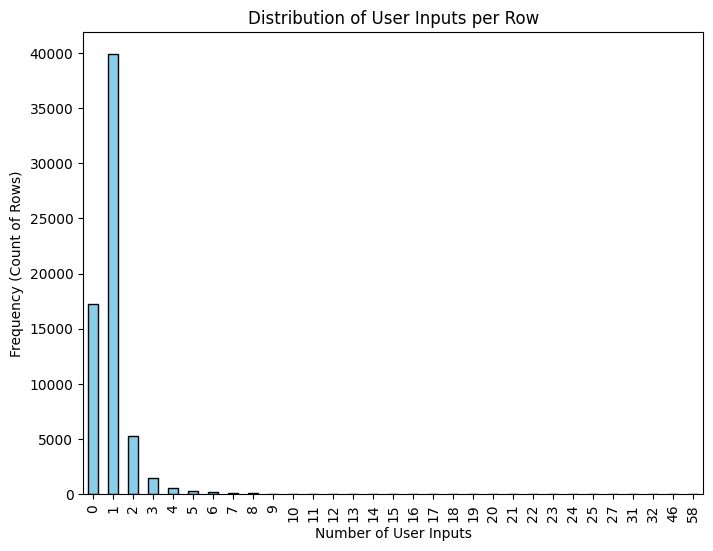

In [85]:
%matplotlib inline
# Visualize the distribution for inputCount
distribution = df_charging_data['inputCount'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of User Inputs per Row")
plt.xlabel("Number of User Inputs")
plt.ylabel("Frequency (Count of Rows)")
plt.show()

In [86]:
# Count rows with more than one user input
count_multiple_inputs = (df_charging_data['inputCount'] > 1).sum()
per_multiple_inputs = round(count_multiple_inputs / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of rows with multiple user inputs: {count_multiple_inputs}")
print(f"Percentage of rows with multiple user inputs: {per_multiple_inputs}%")

Absolute number of rows with multiple user inputs: 7905
Percentage of rows with multiple user inputs: 12.15%


-> More than 10% of the rows have multiple user inputs, so these should be looked at more closely instead of always taking the first dictionary of the list.

Compare the difference between the user inputs in a single session

In [87]:
# Dataframe with all rows with more than one user input
df_multiple_inputs = df_charging_data[df_charging_data["inputCount"] > 1].copy()

# Columns to calculate the range for
columns_of_interest = ["WhPerMile", "kWhRequested", "milesRequested", "minutesAvailable", 
                       "modifiedAt", "requestedDeparture", "userID"]						
# Calculate range for each column safely
for column in columns_of_interest:
    df_multiple_inputs[f"{column}_range"] = df_multiple_inputs["userInputs"].apply(
        lambda x: calculate_range(x, column)
    )

# Select only the relevant columns to create final comparison DataFrame
cols = ["inputCount"] + ["userInputs"] + [f"{col}_range" for col in columns_of_interest]
user_inputs_range_df = df_multiple_inputs[cols]

In [88]:
user_inputs_range_df.head()

,inputCount,userInputs,WhPerMile_range,kWhRequested_range,milesRequested_range,minutesAvailable_range,modifiedAt_range,requestedDeparture_range,userID_range
3,2,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0,0.0,0,0,0 days 00:00:16,0 days 00:00:00,0
17,3,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0,0.0,0,139,0 days 02:41:46,0 days 02:19:00,0
19,2,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil...",0,0.0,0,287,0 days 00:00:09,0 days 04:47:00,0
20,2,"[{'WhPerMile': 350, 'kWhRequested': 42.0, 'mil...",0,14.0,40,44,0 days 01:00:19,0 days 00:44:00,0
31,3,"[{'WhPerMile': 600, 'kWhRequested': 78.0, 'mil...",0,12.0,20,2,0 days 00:02:43,0 days 00:02:00,0


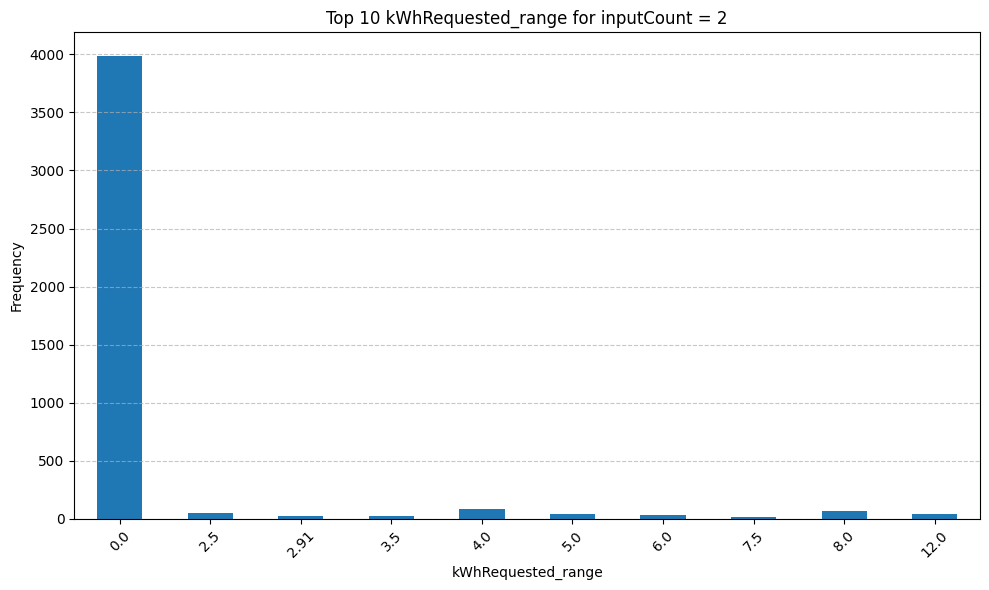

In [89]:
plot_top_n_distribution(user_inputs_range_df, 2, 'kWhRequested_range')

The function above shows the range (max - min value) of the given user inputs in a row, if there were more than one input given. Executing the function with varying parameters leads to very similar results:

Most of the time when multiple user inputs are stored, the inputs the user gave were the exact same, just with different timestamps for "modifiedAt" or a later departure time.
Therefore, it seems like a good solution to always take the last input of the driver and don't do a complicated data aggregation.  
In most cases it won't make a difference regarding the data and where it does it seems to be the most logical way to take the final input of the driver.

Unnest the "userInputs" column

In [90]:
# Process the column to get the last dictionary or an empty dictionary
processed_data = [
    lst[-1] if lst else {} 
    for lst in df_charging_data['userInputs']
]

# Convert the list of dictionaries into a new DataFrame
normalized_df = pd.json_normalize(processed_data)

normalized_df.head()

,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,250.0,25.0,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT",194.0
1,280.0,70.0,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT",4275.0
2,400.0,8.0,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT",344.0
3,400.0,8.0,20.0,65.0,"Thu, 02 Jan 2020 14:00:19 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT",1117.0
4,400.0,16.0,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT",334.0


In [91]:
# Concatenate dataframes and drop userInputs column as the data is now stored in new columns
full_charging_df = pd.concat([df_charging_data.drop(columns=['userInputs']), 
                     normalized_df.drop(columns=['userID'])], axis=1)

In [92]:
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT"
1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT"
2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT"
3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,"Thu, 02 Jan 2020 14:00:19 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT"
4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT"


#### Handle missing values

In [93]:
# Overview of missing values
missing_values = full_charging_df.isnull().sum()
missing_values

id                        0
connectionTime            0
disconnectTime            0
doneChargingTime       4087
kWhDelivered              0
sessionID                 0
siteID                    0
spaceID                   0
stationID                 0
timezone                  0
userID                17215
inputCount                0
WhPerMile             17215
kWhRequested          17215
milesRequested        17215
minutesAvailable      17215
modifiedAt            17215
paymentRequired       17215
requestedDeparture    17215
dtype: int64

In [94]:
print(f"Percentage of rows without registered user': {round(missing_values['userID'] / full_charging_df.shape[0] * 100, 2)}%")
print(f"Percentage of rows without 'doneChargingTime': {round(missing_values['doneChargingTime'] / full_charging_df.shape[0] * 100, 2)}%")

Percentage of rows without registered user': 26.47%
Percentage of rows without 'doneChargingTime': 6.28%


As observed, the column 'doneChargingTime' and all columns related to user inputs contain missing values. Most of these missing values occur because no registered user was present for those rows. Since rows without a registered user account for more than a quarter of the dataset, removing them would result in significant data loss. However, as there is no reliable way to impute values for the missing user inputs, we will leave them as they are.
When it comes to the missing values in the 'doneChargingTime' column, we will investigate them further.

In [95]:
# All rows in charging data with missing values for doneChargingTime
missing_done_charging_time = full_charging_df[full_charging_df['doneChargingTime'].isnull()]

In [96]:
connection_times_missing_dct = missing_done_charging_time["connectionTime"].apply(
    lambda x: pd.to_datetime(x, utc=True))

In [97]:
# Allocation of unique days in the missing doneChargingTime rows
days_with_missing_values = connection_times_missing_dct.dt.date.unique()
len(days_with_missing_values)

414

In [98]:
# Number of instances per unique year
connection_times_missing_dct.dt.year.value_counts()

connectionTime
2021    1458
2018    1273
2019     742
2020     614
Name: count, dtype: int64

It can be seen that the missing values for 'doneChargingTime' are spread over multiple years with 2021 having the most missing values. In these years the missing values are spread over 414 days, so removing the rows with missing values would not create a timeframe in the data with no records at all.
Because we want to later analyze the charging sessions over time, we need to know when the vehicle stopped charging. As we don't want to base our later models on estimated values and the missing values only make up a small part of the data, we will remove the rows with missing values in the 'doneChargingTime' column.

In [99]:
# Drop rows with missing values in the column "doneChargingTime"
full_charging_df = full_charging_df.dropna(subset=["doneChargingTime"])
len(full_charging_df)

60950

#### Exporation and Preparation of the Time Data

First transform the time zones to the correct time zone

In [100]:
time_columns = ["doneChargingTime", "connectionTime", "disconnectTime", "modifiedAt", "requestedDeparture"]

In [101]:
# Transform to pandas datetime datatype
full_charging_df[time_columns] = full_charging_df[time_columns].apply(
    lambda x: pd.to_datetime(x, utc=True))

In [102]:
# Transform the timestamps from UTC to the correct timezone
full_charging_df[time_columns] = full_charging_df[time_columns].apply(
    lambda col: col.dt.tz_convert("America/Los_Angeles"))

In [103]:
# Check new timestamps
full_charging_df["connectionTime"].head()
# -> -08:00 and -07:00 are the offsets from UTC time (-8 hours in winter, -7 in summer)

0   2020-01-02 05:08:54-08:00
1   2020-01-02 05:36:50-08:00
2   2020-01-02 05:56:35-08:00
3   2020-01-02 05:59:58-08:00
4   2020-01-02 06:00:01-08:00
Name: connectionTime, dtype: datetime64[ns, America/Los_Angeles]

Create additional time related Columns for the time data

In [104]:
full_charging_df["doneDisconnectTimespan"] = full_charging_df["disconnectTime"] - full_charging_df["doneChargingTime"]
full_charging_df["connectionTimespan"] = full_charging_df["disconnectTime"] - full_charging_df["connectionTime"]
full_charging_df["doneChargingTimespan"] = full_charging_df["doneChargingTime"] - full_charging_df["connectionTime"]

full_charging_df['connectionMonth'] = full_charging_df['connectionTime'].dt.month
full_charging_df['connectionWeekdayName'] = full_charging_df['connectionTime'].dt.day_name()
full_charging_df["connectionYear"] = full_charging_df["connectionTime"].dt.year
full_charging_df['isWeekend'] = full_charging_df['connectionTime'].dt.weekday >= 5
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour
full_charging_df['disconnectHour'] = full_charging_df['disconnectTime'].dt.hour
full_charging_df['doneChargingHour'] = full_charging_df['doneChargingTime'].dt.hour
full_charging_df['loading_duration'] = (
        (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['connected_duration'] = (
        (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['ratio_loading_to_connected'] = (
        full_charging_df['loading_duration'] / full_charging_df['connected_duration']
)

time_span_columns = ["connectionTimespan", "doneDisconnectTimespan", "doneChargingTimespan"]

Since requestedDeparture is the departure time estimated by the user and minutesAvailable is the length of the session as estimated by the user, the difference between the requestedDeparture and the connectionTime in minutes should be identical with minutesAvailable:

In [105]:
# Timespan between requestedDeparture and connectionTime in minutes
full_charging_df["requestedDeparture-connectionTime"] = (full_charging_df["requestedDeparture"] - full_charging_df["connectionTime"]).dt.total_seconds() / 60

# Check if the values in the columns "requestedDeparture-connectionTime" and "minutesAvailable" are identical
identical = full_charging_df["requestedDeparture-connectionTime"].equals(full_charging_df["minutesAvailable"])
print(f"Features are identical: {identical}")

Features are identical: True


In [106]:
# Remove "requestedDeparture-connectionTime" column, due to redundancy to minutesAvailable
full_charging_df = full_charging_df.drop(columns=["requestedDeparture-connectionTime"])

In [107]:
def plot_histogram(ax, season_df: pd.DataFrame, year: str = None) -> None:
    """
    Helper function to plot a histogram for a single year's data on a given axis.
    """
    # Determine the minimum and maximum month numbers present in the DataFrame
    min_month = season_df['connectionMonth'].min()
    max_month = season_df['connectionMonth'].max()

    # Calculate the number of bins dynamically based on the range of months
    month_bins = max_month - min_month + 1

    # Plotting histogram
    counts, bins, patches = ax.hist(
        season_df['connectionMonth'], bins=month_bins, edgecolor='black',
        rwidth=0.8, range=(min_month - 0.5, max_month + 0.5)
    )

    # Configure the plot
    if year:
        ax.set_title(f"Year {year}")
    ax.set_xlabel('Month')
    ax.set_ylabel('Frequency')

    # Set x-ticks centered under each bar
    ax.set_xticks(np.arange(min_month, max_month + 1))
    ax.set_xticklabels(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][min_month - 1:max_month]
    )

    ax.grid(axis='y', linestyle='--', alpha=0.7)

def plot_hist(dfs_by_year: dict = None, season_df: pd.DataFrame = None, title: str = "") -> None:
    """
    Plots a histogram for either multiple years (dfs_by_year) or a single year's data (season_df).
    """
    if dfs_by_year:
        num_years = len(dfs_by_year)
        fig, axes = plt.subplots(1, num_years, figsize=(15, 5), sharey=True)
        fig.suptitle(title)

        # Ensure axes is iterable for single subplot case
        if num_years == 1:
            axes = [axes]

        for i, (year, df) in enumerate(dfs_by_year.items()):
            plot_histogram(axes[i], df, year)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
        plt.show()
    elif season_df is not None:
        fig, ax = plt.subplots(figsize=(10, 6))
        plot_histogram(ax, season_df)
        plt.title(title)
        plt.tight_layout()
        plt.show()
    else:
        raise ValueError("Provide either 'dfs_by_year' or 'season_df' to plot.")

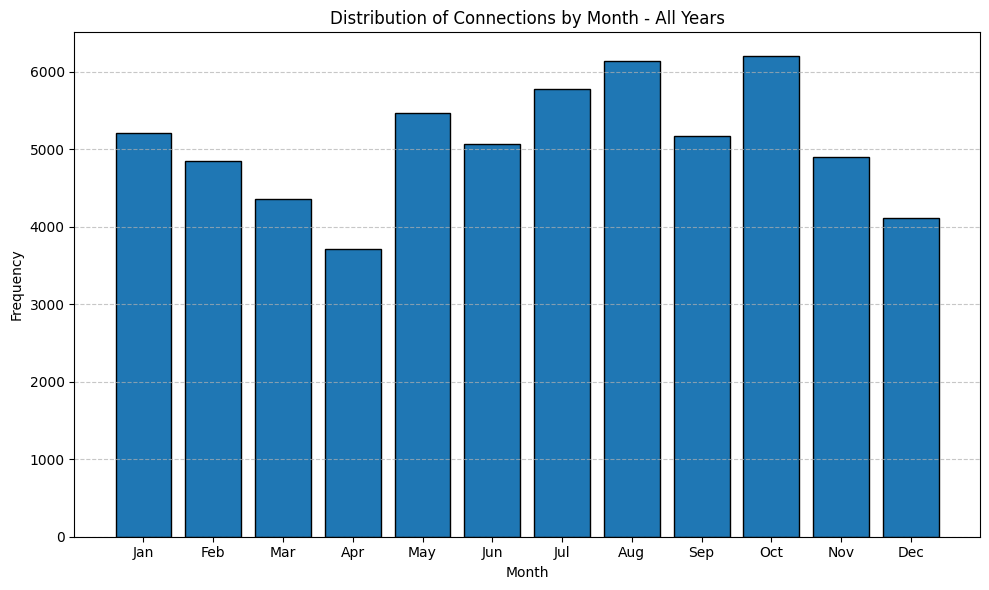

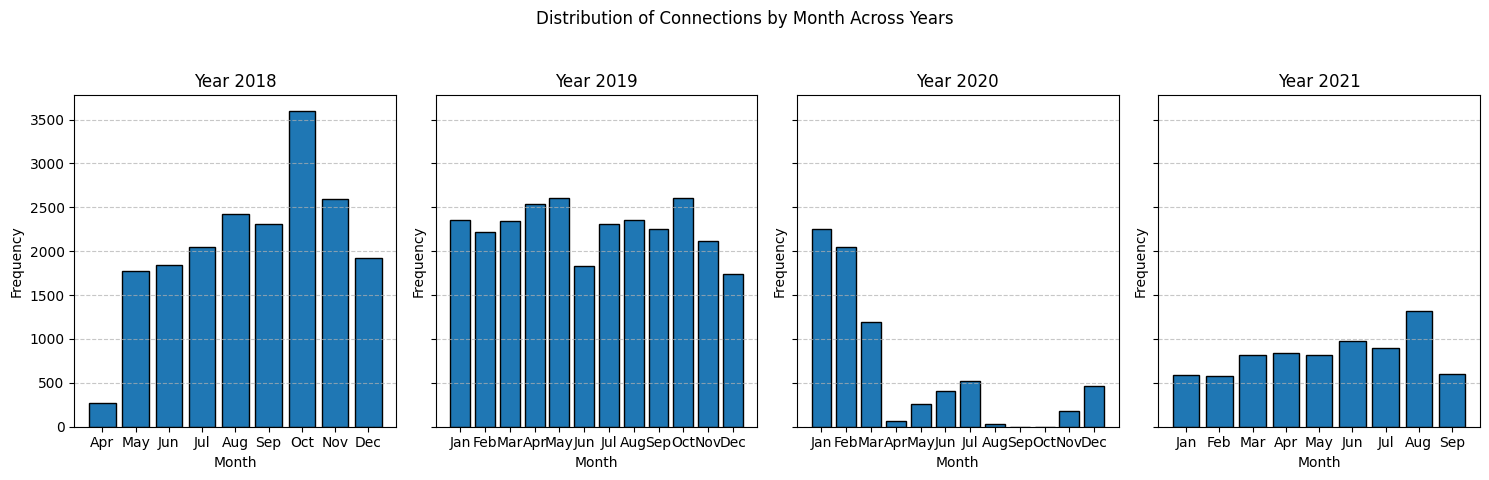

In [108]:
# Extract years from the DataFrame
years = [
    full_charging_df["connectionYear"].min() + year
    for year in range(
        full_charging_df["connectionYear"].max() - full_charging_df["connectionYear"].min() + 1
    )
]

# Create a dictionary of DataFrames by year
dfs_by_year = {
    year: full_charging_df[full_charging_df["connectionYear"] == year]
    for year in years
}

# Plot for all years combined
plot_hist(season_df=full_charging_df, title='Distribution of Connections by Month - All Years')

# Plot for each year individually
plot_hist(dfs_by_year=dfs_by_year, title="Distribution of Connections by Month Across Years")

Here there are a few things to see.
1. we start collecting records from April 2018 to September 2021
2. Somehow in March/April 2020 the data shows a steep fall while it never fully recovers to the old amounts
3. in September and October there don't seem to be any records

**April 2020 fall of records** 
The Fall in April 2020 can most likely be explained with Corona.
As suggested in this website: https://myburbank.com/latest-official-coronavirus-news-concerning-burbank/ (search for "March 22 – Burbank Gives Updated L. A, County Revised Order for Stronger “Safer at Home” Order") it may be due to the lockdown restrictions.

**September/October 2020 no records found**
The data for September and october looks a little bit different and needs further investigation

In [109]:
months = [8, 9, 10, 11]
for month in months:
    monthly_data_2020 = dfs_by_year.get(2020)[dfs_by_year.get(2020)["connectionMonth"] == month]
    print(month ,set(monthly_data_2020['connectionTime'].dt.day))

8 {1, 2, 3}
9 set()
10 set()
11 {18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30}


This data implies that from the 03.08.2020 to the 17.11.2020 we collected no records may due to broken sensors or something similar.

In [110]:
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,1,Thursday,2020,False,5,11,9,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,1,Thursday,2020,False,5,14,12,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,1,Thursday,2020,False,5,16,8,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,1,Thursday,2020,False,5,8,7,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,1,Thursday,2020,False,6,14,10,257.483333,488.650000,0.526928


Now we can explore the time data
Look for negative or NaN values

In [111]:
time_columns

['doneChargingTime',
 'connectionTime',
 'disconnectTime',
 'modifiedAt',
 'requestedDeparture']

In [112]:
for time_column in time_columns:
    print(f"{time_column}: {full_charging_df[time_column].isnull().sum()}")

doneChargingTime: 0
connectionTime: 0
disconnectTime: 0
modifiedAt: 16306
requestedDeparture: 16306


In [113]:
for time_span_column in time_span_columns:
    column_type = full_charging_df[time_span_column].dtype
    negative_timedelta = full_charging_df[time_span_column] < pd.Timedelta(0)
    negative_count = negative_timedelta.sum()
    print(f"{time_span_column}: {negative_count} rows with negative timespans")

connectionTimespan: 0 rows with negative timespans
doneDisconnectTimespan: 4387 rows with negative timespans
doneChargingTimespan: 27 rows with negative timespans


These negative values should not exist because a vehicle can only be charged if it is connected to the station.
Data with a negative doneChargingTimespan (the vehicle was done charging before it was connected) is therefore invalid and should be removed.

In [114]:
# Remove rows with negative doneChargingTimespan
full_charging_df = full_charging_df[full_charging_df['doneChargingTimespan'] >= pd.Timedelta(0)]

Now we can look at the distribution of the negative values for doneDisconnectTimespan (the vehicle was done charging after it was disconnected). These values should also not exist because the vehicle can not be charged after it was disconnected, therefore the doneCharging time should be before the disconnect time or at the same time.

In [115]:
invalid_done_charging = full_charging_df[full_charging_df["doneDisconnectTimespan"] < pd.Timedelta(0)]
# Distribution of the negative values
invalid_done_charging["doneDisconnectTimespan"].describe()

count                           4387
mean     -1 days +23:59:03.982904035
std        0 days 00:01:16.290026860
min                -1 days +23:00:04
25%                -1 days +23:59:01
50%                -1 days +23:59:02
75%                -1 days +23:59:03
max                -1 days +23:59:59
Name: doneDisconnectTimespan, dtype: object

In [116]:
# Number of rows with a negative doneDisconnectTimespan of less than a minute
len(invalid_done_charging[invalid_done_charging["doneDisconnectTimespan"] >= pd.Timedelta(days=-1, hours=23, minutes=59)])

4385

In [117]:
# Difference between the kWhDelivered and the kWhRequested for invalid_done_charging 
kwh_difference = invalid_done_charging["kWhDelivered"] - invalid_done_charging["kWhRequested"]
# Proportion of rows with a negative kWhDifference compared to the amount of rows with non-null values in kWhRequested
proportion = round(((kwh_difference < 0).sum()) / (invalid_done_charging["kWhRequested"].notnull().sum()), 2) * 100
print("Instances where doneDisconnectTimespan is invalid and less kWh were delivered than requested:", proportion,"%") 

Instances where doneDisconnectTimespan is invalid and less kWh were delivered than requested: 96.0 %


We can see that in almost all cases where the doneDisconnectTimespan is negative, the vehicle received less kWh than requested by the user. This is a clear indicator that the vehicle was not done charging when it was disconnected. In addition to that nearly all the negative values are less than a minute long, so it is likely that the vehicle was disconnected while it was still charging and the timestamp for the end of the charging was not recorded correctly, but with a slight delay. Therefore we can assume that the doneChargingTime is the same as the disconnectTime in these cases.

In [118]:
# Set flag for rows with negative doneDisconnectTimespan
full_charging_df['invalidDoneDisconnectTimespan'] = full_charging_df['doneDisconnectTimespan'] < pd.Timedelta(0)

In [119]:
# Remove rows in invalid_done_charging in which the doneDisconnectTimespan is negative with a difference of more than a minute
full_charging_df = full_charging_df[full_charging_df["doneDisconnectTimespan"] >= pd.Timedelta(days=-1, hours=23, minutes=59)]

In [120]:
# Set doneChargingTime to disconnectTime, if flag is set
full_charging_df.loc[full_charging_df['invalidDoneDisconnectTimespan'], 'doneChargingTime'] = full_charging_df['disconnectTime']

# Set doneChargingTimespan to connectionTimespan, if flag is set
full_charging_df.loc[full_charging_df['invalidDoneDisconnectTimespan'], 'doneChargingTimespan'] = full_charging_df['connectionTimespan']

# Set doneDisconnectTimespan to 0, if flag is set
full_charging_df.loc[full_charging_df['invalidDoneDisconnectTimespan'], 'doneDisconnectTimespan'] = pd.Timedelta(0)

In [121]:
# Check for negative values in time_span_columns
for time_span_column in time_span_columns:
    column_type = full_charging_df[time_span_column].dtype
    negative_timedelta = full_charging_df[time_span_column] < pd.Timedelta(0)
    negative_count = negative_timedelta.sum()
    print(f"{time_span_column}: {negative_count} rows with negative timespans")

connectionTimespan: 0 rows with negative timespans
doneDisconnectTimespan: 0 rows with negative timespans
doneChargingTimespan: 0 rows with negative timespans


In [122]:
# Final dataframe
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected,invalidDoneDisconnectTimespan
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,Thursday,2020,False,5,11,9,262.683333,362.350000,0.724944,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,Thursday,2020,False,5,14,12,401.250000,541.516667,0.740974,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,Thursday,2020,False,5,16,8,158.516667,642.783333,0.246610,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,Thursday,2020,False,5,8,7,78.783333,158.683333,0.496481,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,Thursday,2020,False,6,14,10,257.483333,488.650000,0.526928,False


We have now completed the data exploration and the preparation of the time-dependent data. We now need to decide how to deal with the invalid values we found during data exploration. If there is something we haven't seen yet, it will most likely come up when working on the other tasks.

In [123]:
profile = ProfileReport(full_charging_df, title="Profiling Report")
# profile.to_file("full_charging_data_report.html")

In [124]:
# Save the prepared data to feather files
df_weather_filtered.to_feather('../data/weather_burbank_airport.feather')
full_charging_df.to_feather('../data/full_charging_df.feather')